In [1]:
!pip install -q -U transformers huggingface_hub

from huggingface_hub import snapshot_download

# 🔹 Имя модели
model_id = "Qwen/Qwen3-1.7B"

# 🔹 Папка, куда сохранить
local_dir = "qwen3_1_7b"

# 🔹 Качаем всё содержимое модели (веса, конфиги, токенизатор)
snapshot_download(
    repo_id=model_id,
    local_dir=local_dir,
    local_dir_use_symlinks=False,  # чтобы всё реально скачалось, а не символические ссылки
)

print(f"✅ Модель загружена в папку: {local_dir}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 78.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

✅ Модель загружена в папку: qwen3_1_7b


In [ ]:
!pip install -q -U  accelerate torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.8 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# 🔹 Путь к модели
model_path = "./qwen3_1_7b"

# Загружаем токенизатор и модель
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    dtype=torch.bfloat16
)

# 🔹 Функция общения с Qwen
def chat(prompt, max_new_tokens=1000):
    # Формат сообщений в стиле Qwen
    messages = [
        {"Ты — интеллектуальный улучшатель  промптов. "
    "Твоя задача — анализировать пользовательский запрос, "
    "а затем формулировать финальный ответ в синтаксисе Stable Diffusion, описывая визуальные теги. "
    "Говори кратко и профессионально. Не добавляй ничего лишнего, только рассуждение и итоговые теги."
        },
        {"role": "user", "content": prompt},
    ]

    # Преобразуем сообщения в текст с помощью шаблона
    text = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=False
    )

    # Теперь токенизируем как обычно
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.5,
            do_sample=True,
            top_p=0.7,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Декодируем только сгенерированную часть
    reply = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return reply.strip()

# 🔹 Диалоговый цикл
def chat_loop():
    print("🤖 Модель Qwen3 готова к диалогу. Напиши 'exit' чтобы выйти.\n")
    while True:
        user_input = input("Ты: ")
        if user_input.lower().strip() in ["exit", "выход", "quit"]:
            print("👋 До встречи!")
            break

        reply = chat(user_input)
        print(f"Модель: {reply}\n")

# 🔹 Запуск
chat_loop()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🤖 Модель Qwen3 готова к диалогу. Напиши 'exit' чтобы выйти.

Модель: <think>
Хорошо, пользователь просит сгенерировать изображение: молодая девушка стоит на балконе в ночном городе в стиле реалистичной цифровой иллюстрации. Нужно понять, что именно он хочет. Возможно, это для художника или дизайнеров, кто ищет идеи для проекта. Важно учесть детали: ночь, город, балкон, реалистичный стиль.

Начну с того, что описательные элементы: молодая девушка, ночное время, город. Нужно передать атмосферу ночной старины, возможно, с туманом или луной. Балкон должен быть виден, но не слишком вычурным. Стиль реалистичная цифровая иллюстрация — значит, акцент на детализации, точности, но при этом не перегружена. 

Может быть, добавить элементы, которые подчеркнут ночные часы: звезды, тени, возможные объекты вокруг (например, мосты, здания). Также важно, чтобы девушка выглядела живым, с выраженным выражением лица, возможно, с чувством одиночества или красоты. 

Нужно убедиться, что все элементы сочетают

KeyboardInterrupt: Interrupted by user

In [ ]:
!pip install -U bitsandbytes==0.44.1
!pip install triton==2.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 7.1 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.4.0
    Uninstalling triton-3.4.0:
      Successfully uninstalled triton-3.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.8.0+cu126 requires triton==3.4.0; platform_system == "Linux" and platform_machine == "x86_64", but you have triton 2.3.0 which is incompatible.


In [ ]:
import bitsandbytes as bnb
import torch
print("bnb version:", bnb.__version__)
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

bnb version: 0.44.1
torch version: 2.8.0+cu126
CUDA available: True


In [ ]:
!pip install torch==2.3.1+cu121 torchvision==0.18.1+cu121 torchaudio==2.3.1+cu121 \
  --index-url https://download.pytorch.org/whl/cu121
!pip install bitsandbytes==0.44.1

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 24.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 27.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 29.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

KeyboardInterrupt: 

In [ ]:
import bitsandbytes as bnb
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("bnb version:", bnb.__version__)

# Проверим загрузку CUDA-библиотеки
import importlib.util
import os

lib_path = os.path.join(os.path.dirname(bnb.__file__), "libbitsandbytes_cuda121.so")
print("libbitsandbytes_cuda121.so exists:", os.path.exists(lib_path))

Torch: 2.3.1+cu121
CUDA available: True
bnb version: 0.44.1
libbitsandbytes_cuda121.so exists: True


In [ ]:
import os, json, math
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model
import bitsandbytes as bnb

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("bitsandbytes:", bnb.__version__)

# =========================
# 2) ПУТИ И ПАРАМЕТРЫ
# =========================
BASE_MODEL_PATH = "./qwen3_1_7b"     # локально скачанная Qwen/Qwen3-1.7B (base)
TRAIN_JSONL     = "./train.jsonl"    # твой корпус в формате messages JSONL
OUTPUT_DIR      = "./qwen3_1_7b_qlora_adapter"

NUM_EPOCHS = 10
LR = 2e-4
BATCH_SIZE = 1
GRAD_ACCUM = 8
MAX_LEN = 2048
LOG_STEPS = 10

# =========================
# 3) ТОКЕНИЗАТОР И ДАТАСЕТ
# =========================
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

dataset = load_dataset("json", data_files=TRAIN_JSONL, split="train")

def preprocess(example):
    # Преобразуем messages через chat_template → plain text
    text = tokenizer.apply_chat_template(example["messages"], tokenize=False)
    # Токенизация
    tokens = tokenizer(
        text,
        max_length=MAX_LEN,
        truncation=True,
        padding=False,            # паддинг сделает коллатор
        return_tensors=None,
    )
    # ВАЖНО: добавим labels для авторегрессии
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized = dataset.map(preprocess, remove_columns=dataset.column_names, desc="Tokenizing")

# Коллатор поставит паддинг и -100 для паддингов в labels
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# =========================
# 4) МОДЕЛЬ + 4-бит (QLoRA)
# =========================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    quantization_config=bnb_config,
)

# Для тренировки LoRA градиенты должны строиться стабильно — отключим checkpointing
# (если очень нужно — можно включить, но начни без него)
model.gradient_checkpointing_disable()
# На всякий случай (trainer тоже выставит), чтобы не конфликтовать с checkpointing
if getattr(model.config, "use_cache", None) is not None:
    model.config.use_cache = False

# LoRA-конфиг: можно сократить target_modules до ["q_proj", "v_proj"] при дефиците VRAM
peft_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)

# ЯВНО включим обучение только для LoRA-параметров (на некоторых связках это критично)
for name, param in model.named_parameters():
    if "lora" in name.lower():
        param.requires_grad = True
        # приведём обучаемые веса к bf16 (стабильно на T4/L4)
        if param.dtype != torch.bfloat16:
            param.data = param.data.to(torch.bfloat16)
    else:
        param.requires_grad = False

model.train()
model.print_trainable_parameters()

# =========================
# 5) ТРЕНИРОВКА
# =========================
train_steps = math.ceil(len(tokenized) / (BATCH_SIZE * GRAD_ACCUM)) * NUM_EPOCHS
print(f"Train examples: {len(tokenized)} | total steps (approx): {train_steps}")

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    logging_steps=LOG_STEPS,
    save_strategy="epoch",
    save_safetensors=True,
    bf16=True,                    # bfloat16 на T4/Л4 — ок
    optim="paged_adamw_8bit",     # оптимизация под QLoRA
    max_grad_norm=1.0,
    report_to="none",
)

from transformers import logging
logging.set_verbosity_info()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized,
    data_collator=data_collator,
)



trainer.train()

# =========================
# 6) СОХРАНЕНИЕ АДАПТЕРА
# =========================
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("✅ Обучение закончено. LoRA-адаптер сохранён в:", OUTPUT_DIR)

Torch: 2.3.1+cu121
CUDA available: True
bitsandbytes: 0.44.1


Generating train split: 0 examples [00:00, ? examples/s]

Tokenizing:   0%|          | 0/709 [00:00<?, ? examples/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using auto half precision backend


trainable params: 3,211,264 || all params: 1,723,786,240 || trainable%: 0.1863
Train examples: 709 | total steps (approx): 890


skipped Embedding(151936, 2048): 296.75M params
skipped: 296.75M params
***** Running training *****
  Num examples = 709
  Num Epochs = 10
  Instantaneous batch size per device = 1
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 8
  Total optimization steps = 890
  Number of trainable parameters = 3,211,264


Step,Training Loss
10,3.272800
20,1.878700
30,1.419700
40,1.270800
50,1.193900
60,1.164800
70,1.128600
80,1.124000
90,1.033000
100,0.978600


Saving model checkpoint to ./qwen3_1_7b_qlora_adapter/checkpoint-89
loading configuration file ./qwen3_1_7b/config.json
Model config Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 6144,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
   

KeyboardInterrupt: 

In [ ]:
#ЧАТ С ЧЕКПОИНТОМ 445

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# Пути к модели и адаптеру
BASE_MODEL_PATH = "./qwen3_1_7b"
ADAPTER_PATH = "./qwen3_1_7b_qlora_adapter/checkpoint-445"

# Загружаем токенайзер
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Загружаем модель и адаптер
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()

print("✅ Модель с адаптером успешно загружена:", ADAPTER_PATH)

# Системное сообщение — контекст поведения модели
system_prompt = (
    "Ты — интеллектуальный улучшатель визуальных промптов. "
    "Твоя задача — анализировать пользовательский запрос, рассуждать в блоке <think>...</think>, "
    "а затем формулировать финальный ответ в синтаксисе Stable Diffusion, описывая визуальные теги. "
    "Говори кратко и профессионально. Не добавляй ничего лишнего, только рассуждение и итоговые теги."
)

# История диалога
messages = [{"role": "system", "content": system_prompt}]

def chat():
    print("\n💬 Начинай диалог (введи 'exit' для выхода)\n")
    while True:
        user_input = input("Ты: ").strip()
        if user_input.lower() in ["exit", "quit", "выход"]:
            print("🛑 Диалог завершён.")
            break

        messages.append({"role": "user", "content": user_input})

        # Применяем chat template Qwen
        text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text, return_tensors="pt").to("cuda")

        # Генерация
        with torch.inference_mode():
            output = model.generate(
                **inputs,
                max_new_tokens=256,
                temperature=0.6,
                top_p=0.9,
                do_sample=True,
                repetition_penalty=1.05,
            )

        # Декодируем ответ
        response = tokenizer.decode(output[0], skip_special_tokens=True)
        response = response.split("assistant")[-1].strip()

        # Выводим
        print(f"\n🧠 Модель:\n{response}\n")

        # Добавляем ответ в историю
        messages.append({"role": "assistant", "content": response})

# Запуск диалога
chat()

loading file vocab.json
loading file merges.txt
loading file tokenizer.json
loading file added_tokens.json
loading file special_tokens_map.json
loading file tokenizer_config.json
loading file chat_template.jinja
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
loading configuration file ./qwen3_1_7b/config.json
`torch_dtype` is deprecated! Use `dtype` instead!
Model config Qwen3Config {
  "architectures": [
    "Qwen3ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 6144,
  "layer_types": [
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",
    "full_attention",

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

loading configuration file ./qwen3_1_7b/generation_config.json
Generate config GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "pad_token_id": 151643,
  "temperature": 0.6,
  "top_k": 20,
  "top_p": 0.95
}

Could not locate the custom_generate/generate.py inside ./qwen3_1_7b.


✅ Модель с адаптером успешно загружена: ./qwen3_1_7b_qlora_adapter/checkpoint-445

💬 Начинай диалог (введи 'exit' для выхода)


🧠 Модель:
<think>
Пользователь хочет улучшить качество изображения. Нужно повысить четкость, текстуру и общее видение.
</think>

analyze image quality, enhance resolution, sharpen details, improved lighting, professional tone, detailed texture


🧠 Модель:
<think>
Нужно избавить композицию от человека на фоне, создав чистый и ровный световой баланс.
</think>

remove person from background, clean light, balanced tones, realistic texture, focus on subject, seamless composition


🧠 Модель:
<think>
Нужно улучшить текстуру кожи, снизить резкость и создать естественный вид.
</think>

improve skin texture, reduced noise, natural tones, smooth highlights, realistic detail, focus on subject


🧠 Модель:
<think>
Пользователь хочет аниме-эффект. Нужно создать мягкие тени, характерные цвета и винтажную атмосферу.
</think>

anime style, soft shadows, characteristic colors, v

KeyboardInterrupt: Interrupted by user

In [ ]:
# =========================
#  💬 ЧАТ С ФАЙНТЮНЕННОЙ МОДЕЛЬЮ QWEN3 + QLORA
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

# 🔹 Пути
BASE_MODEL_PATH = "./qwen3_1_7b"
ADAPTER_PATH    = "./qwen3_1_7b_qlora_adapter"

# 🔹 Загружаем токенизатор и базовую модель
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# 🔹 Подключаем обученный адаптер
model = PeftModel.from_pretrained(model, ADAPTER_PATH)
model.eval()

# =========================
# 💬 Функция общения
# =========================

def chat(messages, max_new_tokens=300, temperature=0.7, top_p=0.9):
    """messages — список {role, content}"""
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return response.strip()

# =========================
# 💬 Диалоговый цикл
# =========================
print("🤖 Модель готова к диалогу! Напиши 'exit' чтобы выйти.\n")

history = [{"role": "system", "content": "Ты — ассистент, который улучшает визуальные запросы для обработки фотографий."}]

while True:
    user_input = input("Ты: ")
    if user_input.lower().strip() in ["exit", "выход", "quit"]:
        print("👋 До встречи!")
        break

    history.append({"role": "user", "content": user_input})
    reply = chat(history)
    print(f"Модель: {reply}\n")
    history.append({"role": "assistant", "content": reply})

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🤖 Модель готова к диалогу! Напиши 'exit' чтобы выйти.

Модель: <think>

</think>

Добавить естественную освещённость, смягчённые тени и равномерное освещение. Создать гармоничное изображение.

Модель: <think>

</think>

Добавить ретушевку и мягкий контраст, придать изображению классический стиль 80-х.

Модель: <think>
</think>

Добавить розовый тон, создать романтическое и нежное изображение.

Ты: улучши фото 
Модель: <think>
</think>

Добавить мягкий контраст, улучшить цветовую гладкость и естественное освещение. Создать чистое и красивое изображение.



KeyboardInterrupt: Interrupted by user

In [ ]:
# fix_quotes.py
import re

# путь к твоему датасету
input_path = "train.jsonl"
output_path = "train_fixed.jsonl"

# читаем файл
with open(input_path, "r", encoding="utf-8") as f:
    text = f.read()

# заменяем типографские кавычки на стандартные
# “ ” -> "
# ‘ ’ -> '
text_fixed = (
    text.replace("“", '"')
         .replace("”", '"')
         .replace("‘", "'")
         .replace("’", "'")
)

# можно дополнительно убрать неразрывные пробелы и другие артефакты
text_fixed = re.sub(r"\u00A0", " ", text_fixed)

# сохраняем исправленный вариант
with open(output_path, "w", encoding="utf-8") as f:
    f.write(text_fixed)

print("✅ Готово! Исправленный датасет сохранён в", output_path)

✅ Готово! Исправленный датасет сохранён в train_fixed.jsonl


In [ ]:
import shutil
import os

# Путь к твоему лучшему чекпоинту
CHECKPOINT_PATH = "./qwen3_1_7b_qlora_adapter/checkpoint-445"
EXPORT_PATH = "./qwen3_1_7b_qlora_lora_700_v1"

# Копируем чекпоинт в отдельную финальную папку
shutil.copytree(CHECKPOINT_PATH, EXPORT_PATH, dirs_exist_ok=True)

# Упаковываем в ZIP (для скачивания)
shutil.make_archive(EXPORT_PATH, 'zip', EXPORT_PATH)

print(f"✅ Адаптер сохранён и упакован: {EXPORT_PATH}.zip")

✅ Адаптер сохранён и упакован: ./qwen3_1_7b_qlora_lora_700_v1.zip


**Подключение адаптера и сбор метрик**

In [2]:
import os

zip_path = "qwen3_1_7b_qlora_lora_700_v1.zip"

# Проверяем существование
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Файл {zip_path} не найден!")

# Создаём папку под адаптер (по имени zip)
extract_dir = zip_path.replace(".zip", "")

# Если папка уже была — удаляем
if os.path.exists(extract_dir):
    print(f"⚠️ Папка {extract_dir} уже существует — удаляю, чтобы распаковать заново…")
    !rm -r "{extract_dir}"

# Распаковка
print("📂 Распаковка ZIP…")
!unzip -o "{zip_path}" -d "{extract_dir}" > /dev/null

print(f"✅ Готово! Адаптер распакован в папку: {extract_dir}")

print("\n📄 Содержимое папки:")
!ls -l "{extract_dir}"

📂 Распаковка ZIP…
✅ Готово! Адаптер распакован в папку: qwen3_1_7b_qlora_lora_700_v1

📄 Содержимое папки:
total 28508
-rw-r--r-- 1 root root      874 Nov  5 14:32 adapter_config.json
-rw-r--r-- 1 root root  6452200 Nov  5 14:32 adapter_model.safetensors
-rw-r--r-- 1 root root      707 Nov  5 14:32 added_tokens.json
-rw-r--r-- 1 root root     4168 Nov  5 14:32 chat_template.jinja
-rw-r--r-- 1 root root  1671853 Nov  5 14:32 merges.txt
-rw-r--r-- 1 root root  6785402 Nov  5 14:32 optimizer.pt
-rw-r--r-- 1 root root     5178 Nov  5 14:32 README.md
-rw-r--r-- 1 root root    14244 Nov  5 14:32 rng_state.pth
-rw-r--r-- 1 root root     1064 Nov  5 14:32 scheduler.pt
-rw-r--r-- 1 root root      613 Nov  5 14:32 special_tokens_map.json
-rw-r--r-- 1 root root     5404 Nov  5 14:32 tokenizer_config.json
-rw-r--r-- 1 root root 11422753 Nov  5 14:32 tokenizer.json
-rw-r--r-- 1 root root     7909 Nov  5 14:32 trainer_state.json
-rw-r--r-- 1 root root     5432 Nov  5 14:32 training_args.bin
-rw-r--r-

In [ ]:
!pip install -q evaluate bert-score datasets peft transformers accelerate bitsandbytes rouge_score sacrebleu

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import torch
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import evaluate

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# =========================
# 1) ПУТИ
# =========================
BASE_MODEL_PATH = "./qwen3_1_7b"                    # базовая Qwen3-1.7B
ADAPTER_DIR     = "./qwen3_1_7b_qlora_lora_700_v1"  # ТВОЙ распакованный LoRA-адаптер
EVAL_JSONL      = "./eval.jsonl"                    # новый eval-сет (100 примеров)

assert os.path.exists(ADAPTER_DIR), f"Нет папки {ADAPTER_DIR}"
assert os.path.exists(EVAL_JSONL), f"Нет файла {EVAL_JSONL}"

# =========================
# 2) ЗАГРУЗКА МОДЕЛИ + АДАПТЕРА
# =========================
print("\n🔹 Загружаю токенизатор...")
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("🔹 Загружаю базовую модель...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.bfloat16,   # безопасно для Qwen3
)

print("🔹 Подключаю LoRA-адаптер...")
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()

system_prompt = (
    "Ты — интеллектуальный улучшатель визуальных промптов. "
    "Сначала рассуждаешь в блоке <think>...</think> на естественном языке, "
    "затем выдаёшь финальный ответ в синтаксисе Stable Diffusion: "
    "англоязычные теги через запятую, без лишнего текста."
)

# =========================
# 3) ФУНКЦИИ: ВЫДЕЛИТЬ ТЕГИ + СГЕНЕРИРОВАТЬ ОТВЕТ
# =========================
def extract_tags(text: str) -> str:
    """
    Оставляем только финальную часть после </think>,
    т.е. чистый SD-промпт. Если <think> нет — возвращаем всё.
    """
    if "</think>" in text:
        return text.split("</think>", 1)[1].strip()
    return text.strip()

def generate_answer(user_text: str, max_new_tokens: int = 256) -> str:
    """
    Генерим ответ модели по user-промпту,
    возвращаем ПОЛНЫЙ текст (и <think>, и теги).
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_text},
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.6,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )

    full = tokenizer.decode(out[0], skip_special_tokens=True)
    # отрезаем исходный промпт, оставляем только сгенерированную часть
    gen_part = full[len(chat_text):].strip()
    return gen_part

# =========================
# 4) ЗАГРУЗКА EVAL-ДАТАСЕТА
# =========================
print("\n🔹 Загружаю eval.jsonl...")
eval_dataset = load_dataset("json", data_files=EVAL_JSONL, split="train")
print("Примеров в eval:", len(eval_dataset))
print("Пример 0:", eval_dataset[0])

# Можно ограничить размер eval для быстрых тестов:
MAX_EVAL_EXAMPLES = None   # или, например, 100
if MAX_EVAL_EXAMPLES is not None:
    eval_dataset = eval_dataset.select(range(min(MAX_EVAL_EXAMPLES, len(eval_dataset))))

print("Будем оценивать примеров:", len(eval_dataset))

# =========================
# 5) ПРОГОН МОДЕЛИ ПО EVAL
# =========================
preds = []
refs  = []
users = []

print("\n🔹 Генерация ответов модели на eval-сете...")
for ex in tqdm(eval_dataset):
    messages = ex["messages"]
    user_msg = next(m["content"] for m in messages if m["role"] == "user")
    ref_assistant = next(m["content"] for m in messages if m["role"] == "assistant")

    gen_full = generate_answer(user_msg)

    pred_tags = extract_tags(gen_full)
    ref_tags  = extract_tags(ref_assistant)

    preds.append(pred_tags)
    refs.append(ref_tags)
    users.append(user_msg)

print("✅ Генерация завершена.")

# =========================
# 6) ПОДСЧЁТ МЕТРИК: ROUGE, BLEU, BERTScore
# =========================
print("\n🔹 Считаю метрики... (ROUGE, BLEU, BERTScore)")

rouge = evaluate.load("rouge")
bleu  = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

# BLEU требует список списков для references
bleu_result = bleu.compute(
    predictions=preds,
    references=[[r] for r in refs],
)

rouge_result = rouge.compute(
    predictions=preds,
    references=refs,
)

# BERTScore — тяжёлая метрика, но зато смысловая; xlm-roberta-large — мультиязычная
bertscore_result = bertscore.compute(
    predictions=preds,
    references=refs,
    model_type="xlm-roberta-large",
    lang="en",         # микс RU/EN, но теги у тебя в основном EN → норм
    rescale_with_baseline=True,
)

bert_f1_mean = float(sum(bertscore_result["f1"]) / len(bertscore_result["f1"]))

print("\n===== 📊 РЕЗУЛЬТАТЫ =====")
print("BLEU:", round(bleu_result["bleu"], 4))
print("ROUGE-1:", round(rouge_result["rouge1"], 4))
print("ROUGE-2:", round(rouge_result["rouge2"], 4))
print("ROUGE-L:", round(rouge_result["rougeL"], 4))
print("BERTScore F1 (mean):", round(bert_f1_mean, 4))

# =========================
# 7) ПАРА ПРИМЕРОВ ДЛЯ ГЛАЗ
# =========================
print("\n===== 🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ =====")
for i in range(3):
    print(f"\n# {i+1}")
    print("USER: ", users[i])
    print("REF : ", refs[i])
    print("PRED: ", preds[i])

Torch: 2.9.0+cu126
CUDA available: True

🔹 Загружаю токенизатор...
🔹 Загружаю базовую модель...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🔹 Подключаю LoRA-адаптер...

🔹 Загружаю eval.jsonl...
Примеров в eval: 96
Пример 0: {'messages': [{'role': 'user', 'content': 'Сделай фото ярче и контрастнее'}, {'role': 'assistant', 'content': '<think>Пользователь хочет улучшить экспозицию и контраст изображения. Нужно увеличить яркость и усилить разницу между светами и тенями.</think>\nbright lighting, high contrast, vivid colors, enhanced exposure, keep original composition, same framing, realistic lighting'}]}
Будем оценивать примеров: 96

🔹 Генерация ответов модели на eval-сете...


100%|██████████| 96/96 [06:14<00:00,  3.90s/it]


✅ Генерация завершена.

🔹 Считаю метрики... (ROUGE, BLEU, BERTScore)


...

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]


===== 📊 РЕЗУЛЬТАТЫ =====
BLEU: 0.2019
ROUGE-1: 0.4258
ROUGE-2: 0.1696
ROUGE-L: 0.3464
BERTScore F1 (mean): 0.5126

===== 🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ =====

# 1
USER:  Сделай фото ярче и контрастнее
REF :  bright lighting, high contrast, vivid colors, enhanced exposure, keep original composition, same framing, realistic lighting
PRED:  vivid lighting, enhanced contrast, sharp details, bright tones, enhanced color, rich highlights

# 2
USER:  Убери человека с заднего плана
REF :  remove background person, clean scene, seamless edit, natural background, keep original composition, same framing, realistic lighting
PRED:  remove person, clean background, focus on subject, cinematic tone, realistic lighting

# 3
USER:  Добавь мягкий золотой свет на лицо
REF :  soft golden light on face, warm glow, diffused lighting, gentle shadows, keep original composition, same framing, realistic lighting
PRED:  golden glow, warm tones, soft highlights, delicate light, radiant atmosphere, luxurious glow


**Посмотрим базовую гвен на тех же примерах**

In [ ]:
import os
import json
import torch
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import evaluate

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# =========================
# 1) ПУТИ
# =========================
BASE_MODEL_PATH = "./qwen3_1_7b"   # базовая Qwen3-1.7B
EVAL_JSONL      = "./eval.jsonl"   # тот же eval, что и для LoRA

assert os.path.exists(BASE_MODEL_PATH), f"Нет папки {BASE_MODEL_PATH}"
assert os.path.exists(EVAL_JSONL),      f"Нет файла {EVAL_JSONL}"

# =========================
# 2) ЗАГРУЗКА БАЗОВОЙ МОДЕЛИ (БЕЗ LoRA)
# =========================
print("\n🔹 Загружаю токенизатор...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("🔹 Загружаю базовую модель (без LoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)
model = base_model.eval()

system_prompt = (
    "Ты — интеллектуальный улучшатель визуальных промптов. "
    "Сначала рассуждаешь в блоке <think>...</think> на естественном языке, "
    "затем выдаёшь финальный ответ в синтаксисе Stable Diffusion: "
    "англоязычные теги через запятую, без лишнего текста."
)

# =========================
# 3) ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# =========================
def extract_tags(text: str) -> str:
    """
    Оставляем только финальную часть после </think>,
    т.е. чистый SD-промпт. Если <think> нет — возвращаем всё.
    """
    if "</think>" in text:
        return text.split("</think>", 1)[1].strip()
    return text.strip()

def generate_answer_base(user_text: str, max_new_tokens: int = 256) -> str:
    """
    Генерим ответ БАЗОВОЙ моделью.
    Возвращаем полную строку (и <think>, и теги).
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_text},
    ]
    chat_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.6,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )

    full = tokenizer.decode(out[0], skip_special_tokens=True)
    gen_part = full[len(chat_text):].strip()
    return gen_part

# =========================
# 4) ЗАГРУЗКА EVAL-ДАТАСЕТА
# =========================
print("\n🔹 Загружаю eval.jsonl...")
eval_dataset = load_dataset("json", data_files=EVAL_JSONL, split="train")
print("Примеров в eval:", len(eval_dataset))
print("Пример 0:", eval_dataset[0])

MAX_EVAL_EXAMPLES = None  # если хочешь быстрее — поставь число
if MAX_EVAL_EXAMPLES is not None:
    eval_dataset = eval_dataset.select(range(min(MAX_EVAL_EXAMPLES, len(eval_dataset))))

print("Будем оценивать примеров:", len(eval_dataset))

# =========================
# 5) ПРОГОН БАЗОВОЙ МОДЕЛИ ПО EVAL
# =========================
preds = []
refs  = []
users = []

print("\n🔹 Генерация ответов базовой модели на eval-сете...")
for ex in tqdm(eval_dataset):
    messages = ex["messages"]
    user_msg = next(m["content"] for m in messages if m["role"] == "user")
    ref_assistant = next(m["content"] for m in messages if m["role"] == "assistant")

    gen_full = generate_answer_base(user_msg)

    pred_tags = extract_tags(gen_full)
    ref_tags  = extract_tags(ref_assistant)

    preds.append(pred_tags)
    refs.append(ref_tags)
    users.append(user_msg)

print("✅ Генерация завершена.")

# =========================
# 6) МЕТРИКИ: ROUGE, BLEU, BERTScore
# =========================
print("\n🔹 Считаю метрики базовой модели...")

rouge = evaluate.load("rouge")
bleu  = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

bleu_result = bleu.compute(
    predictions=preds,
    references=[[r] for r in refs],
)

rouge_result = rouge.compute(
    predictions=preds,
    references=refs,
)

bertscore_result = bertscore.compute(
    predictions=preds,
    references=refs,
    model_type="xlm-roberta-large",
    lang="en",                 # теги в основном EN
    rescale_with_baseline=True,
)
bert_f1_mean = float(sum(bertscore_result["f1"]) / len(bertscore_result["f1"]))

print("\n===== 📊 РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ =====")
print("BLEU:",      round(bleu_result["bleu"], 4))
print("ROUGE-1:",   round(rouge_result["rouge1"], 4))
print("ROUGE-2:",   round(rouge_result["rouge2"], 4))
print("ROUGE-L:",   round(rouge_result["rougeL"], 4))
print("BERTScore F1 (mean):", round(bert_f1_mean, 4))

# =========================
# 7) ПАРУ ПРИМЕРОВ ДЛЯ СРАВНЕНИЯ
# =========================
print("\n===== 🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ БАЗОВОЙ МОДЕЛИ =====")
for i in range(3):
    print(f"\n# {i+1}")
    print("USER: ", users[i])
    print("REF : ", refs[i])
    print("PRED: ", preds[i])

Torch: 2.9.0+cu126
CUDA available: True

🔹 Загружаю токенизатор...
🔹 Загружаю базовую модель (без LoRA)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


🔹 Загружаю eval.jsonl...
Примеров в eval: 96
Пример 0: {'messages': [{'role': 'user', 'content': 'Сделай фото ярче и контрастнее'}, {'role': 'assistant', 'content': '<think>Пользователь хочет улучшить экспозицию и контраст изображения. Нужно увеличить яркость и усилить разницу между светами и тенями.</think>\nbright lighting, high contrast, vivid colors, enhanced exposure, keep original composition, same framing, realistic lighting'}]}
Будем оценивать примеров: 96

🔹 Генерация ответов базовой модели на eval-сете...


100%|██████████| 96/96 [20:16<00:00, 12.67s/it]


✅ Генерация завершена.

🔹 Считаю метрики базовой модели...



===== 📊 РЕЗУЛЬТАТЫ БАЗОВОЙ МОДЕЛИ =====
BLEU: 0.0019
ROUGE-1: 0.0629
ROUGE-2: 0.0083
ROUGE-L: 0.0464
BERTScore F1 (mean): -0.1445

===== 🔍 ПРИМЕРЫ ПРЕДСКАЗАНИЙ БАЗОВОЙ МОДЕЛИ =====

# 1
USER:  Сделай фото ярче и контрастнее
REF :  bright lighting, high contrast, vivid colors, enhanced exposure, keep original composition, same framing, realistic lighting
PRED:  d more contrasty. Let me think about how to approach this.

First, I need to recall what parameters in image editing affect brightness and contrast. Brightness usually relates to the overall light level, while contrast is about the difference between light and dark areas. 

For brightness, increasing the brightness value in the image adjustment tools would make the image appear brighter. But since the user didn't specify a particular tool, I should suggest a general method. In most image editors, you can adjust the brightness by adding a value (like +10) or using a slider.

Contrast can be adjusted by increasing the contrast val

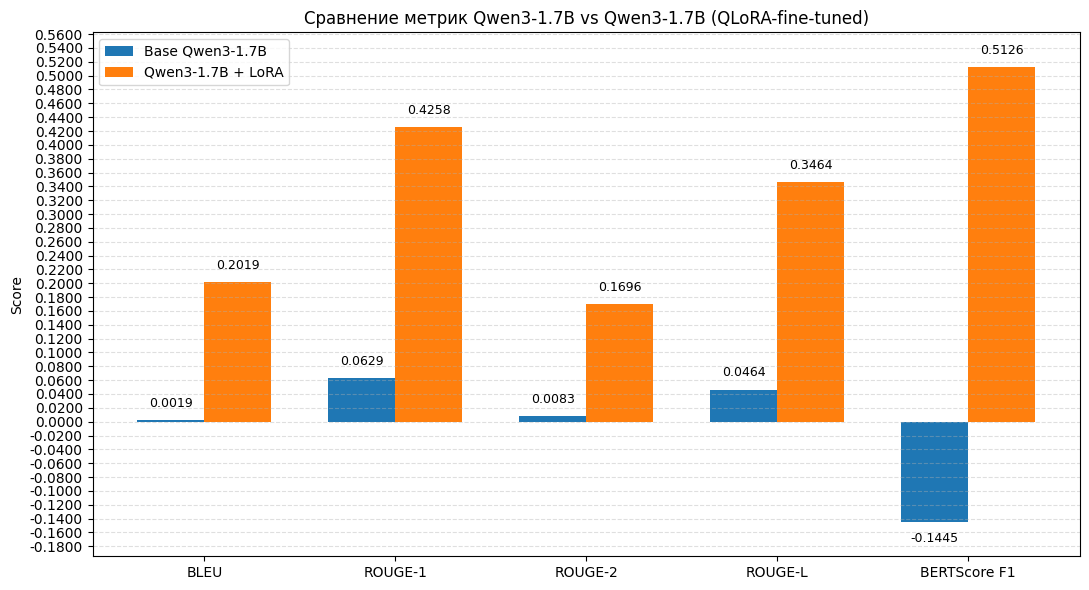

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# Метрики
metrics = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore F1"]

base_scores = [0.0019, 0.0629, 0.0083, 0.0464, -0.1445]
lora_scores = [0.2019, 0.4258, 0.1696, 0.3464, 0.5126]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

bars_base = plt.bar(x - width/2, base_scores, width, label="Base Qwen3-1.7B")
bars_lora = plt.bar(x + width/2, lora_scores, width, label="Qwen3-1.7B + LoRA")

plt.ylabel("Score")
plt.title("Сравнение метрик Qwen3-1.7B vs Qwen3-1.7B (QLoRA-fine-tuned)")
plt.xticks(x, metrics)
plt.legend()

# === Форматирование оси Y ===
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("%.4f"))   # формат меток
plt.gca().yaxis.set_major_locator(MultipleLocator(0.02))          # шаг 0.02

# === Сетка ===
plt.grid(axis='y', linestyle='--', alpha=0.4)

# === Подписи над столбцами ===
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        offset = 0.015  # смещение подписей вверх/вниз

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (offset if height >= 0 else -offset),
            f"{height:.4f}",
            ha="center",
            va="bottom" if height >= 0 else "top",
            fontsize=9,
        )

autolabel(bars_base)
autolabel(bars_lora)

# === Авторасширение границ Y, чтобы подписи не вылезали ===
all_values = base_scores + lora_scores
plt.ylim(min(all_values) - 0.05, max(all_values) + 0.05)

plt.tight_layout()
plt.show()

In [7]:
# =========================
#  💬 ЧАТ С ФАЙНТЮНЕННОЙ МОДЕЛЬЮ QWEN3 + QLORA
# =========================

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

# 🔹 Пути
BASE_MODEL_PATH = "./qwen3_1_7b"
ADAPTER_PATH    = "./qwen3_1_7b_qlora_lora_700_v1"

# 🔹 Загружаем токенизатор и базовую модель
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_PATH,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

# 🔹 Подключаем обученный адаптер
model = PeftModel.from_pretrained(model, ADAPTER_PATH)
model.eval()

# =========================
# 💬 Функция общения
# =========================

def chat(messages, max_new_tokens=500, temperature=0.7, top_p=0.9):
    """messages — список {role, content}"""
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
    return response.strip()

# =========================
# 💬 Диалоговый цикл
# =========================
print("🤖 Модель готова к диалогу! Напиши 'exit' чтобы выйти.\n")

history = [
    {
        "role": "system",
        "content": (
            "Ты — интеллектуальный улучшатель визуальных промптов. "
            "Сначала рассуждаешь в блоке <think>...</think> на естественном языке, "
            "затем выдаёшь финальный ответ в синтаксисе Stable Diffusion: "
            "англоязычные теги через запятую, без лишнего текста."
        )
    }
]

while True:
    user_input = input("Ты: ")
    if user_input.lower().strip() in ["exit", "выход", "quit"]:
        print("👋 До встречи!")
        break

    history.append({"role": "user", "content": user_input})
    reply = chat(history)
    print(f"Модель: {reply}\n")
    history.append({"role": "assistant", "content": reply})

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

🤖 Модель готова к диалогу! Напиши 'exit' чтобы выйти.

Ты: Сгенерируй молодая девушка стоит на балконе в ночном городе, в стиле реалистичной цифровой иллюстрации
Модель: <think>
Пользователь хочет детализированную городскую сцену с молодой женщиной. Нужно создать реалистичный свет и тени, сохраняя пропорции.
</think>

vintage night scene, young woman standing on balcony, realistic lighting, detailed composition, urban atmosphere, cinematic lighting

Ты: сгененирй собаку подводой 
Модель: <think>
Пользователь хочет создать портрет собаки под водой. Нужно использовать эффект отражения и контраст.
</think>

submerged pet portrait, aquarium reflection, detailed fur texture, water surface, realistic lighting, aquatic atmosphere



KeyboardInterrupt: Interrupted by user